In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import mne

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, BatchNormalization, LeakyReLU, Dense, Lambda, Reshape, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.losses import mse
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras import backend as K

In [7]:
import mne

raw = mne.io.read_raw_gdf(r"C:\Users\Wendy\Documents\College\Skripsi\MyCode\GithubVae\EEG-Data-Augmentation-using-Variational-Autoencoder\data\A01E.gdf", preload=True)

print(raw.info)
print(raw.get_data().shape)


Extracting EDF parameters from C:\Users\Wendy\Documents\College\Skripsi\MyCode\GithubVae\EEG-Data-Augmentation-using-Variational-Autoencoder\data\A01E.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 686999  =      0.000 ...  2747.996 secs...


c:\Users\Wendy\miniconda3\envs\eeg_tf\lib\contextlib.py:126: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


<Info | 8 non-empty values
 bads: []
 ch_names: EEG-Fz, EEG-0, EEG-1, EEG-2, EEG-3, EEG-4, EEG-5, EEG-C3, EEG-6, ...
 chs: 25 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 2005-01-19 12:00:00 UTC
 nchan: 25
 projs: []
 sfreq: 250.0 Hz
 subject_info: 4 items (dict)
>
(25, 687000)


In [55]:
import numpy as np
import mne

all_trials = []

for filepath in files:

    print("Processing:", filepath)

    raw = mne.io.read_raw_gdf(filepath, preload=True, verbose=False)

    # Keep EEG only (remove EOG)
    raw.pick_types(eeg=True)

    events, event_id = mne.events_from_annotations(raw)

    # Skip evaluation files (they only contain 783)
    if '769' not in event_id:
        print("Skipping E file")
        continue

    # Keep only motor imagery events
    mi_event_id = {
        '769': event_id['769'],
        '770': event_id['770'],
        '771': event_id['771'],
        '772': event_id['772'],
    }

    epochs = mne.Epochs(
        raw,
        events,
        event_id=mi_event_id,
        tmin=0,
        tmax=4,
        baseline=None,
        preload=True,
        event_repeated='drop',
        verbose=False
    )

    print("Trials extracted:", len(epochs))

    X = epochs.get_data()  # (trials, channels, samples)
    all_trials.append(X)


# Concatenate all subjects
X_all = np.concatenate(all_trials, axis=0)

# Convert to microvolts (VERY IMPORTANT)
X_all = X_all * 1e6

# Add CNN dimension
X_all = np.expand_dims(X_all, axis=-1)

print("Final shape:", X_all.shape)


Processing: C:\Users\Wendy\Documents\College\Skripsi\MyCode\GithubVae\EEG-Data-Augmentation-using-Variational-Autoencoder\data\A01E.gdf


c:\Users\Wendy\miniconda3\envs\eeg_tf\lib\contextlib.py:126: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '783']
Skipping E file
Processing: C:\Users\Wendy\Documents\College\Skripsi\MyCode\GithubVae\EEG-Data-Augmentation-using-Variational-Autoencoder\data\A01T.gdf


c:\Users\Wendy\miniconda3\envs\eeg_tf\lib\contextlib.py:126: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Trials extracted: 288
Processing: C:\Users\Wendy\Documents\College\Skripsi\MyCode\GithubVae\EEG-Data-Augmentation-using-Variational-Autoencoder\data\A02E.gdf


...

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Trials extracted: 288
Processing: C:\Users\Wendy\Documents\College\Skripsi\MyCode\GithubVae\EEG-Data-Augmentation-using-Variational-Autoencoder\data\A09E.gdf


c:\Users\Wendy\miniconda3\envs\eeg_tf\lib\contextlib.py:126: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '783']
Skipping E file
Processing: C:\Users\Wendy\Documents\College\Skripsi\MyCode\GithubVae\EEG-Data-Augmentation-using-Variational-Autoencoder\data\A09T.gdf


c:\Users\Wendy\miniconda3\envs\eeg_tf\lib\contextlib.py:126: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Trials extracted: 288
Final shape: (2592, 25, 1001, 1)


In [56]:
# 80:20 training-validation split
X_train, X_test = train_test_split(train_data,  test_size=0.2)

In [57]:
# VAE model
input_shape=(X_train.shape[1:])
batch_size = 32
kernel_size = 5
filters = 16
latent_dim = 2
epochs = 1000

# reparameterization
def sampling(args): 
    z_mean, z_log_var = args
    batch = K.shape(z_mean)[0]
    dim = K.int_shape(z_mean)[1]
    epsilon = K.random_normal(shape=(batch, dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon




# encoder
inputs = Input(shape=input_shape, name='encoder_input')
x = inputs

filters = filters* 2
x = Conv2D(filters=filters,kernel_size=(1, 50),strides=(1,25),)(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.2)(x)


filters = filters* 2
x = Conv2D(filters=filters,kernel_size=(22, 1),)(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.2)(x)

shape = K.int_shape(x)

x = Flatten()(x)
x = Dense(16, activation='relu')(x)
z_mean = Dense(latent_dim, name='z_mean')(x)
z_log_var = Dense(latent_dim, name='z_log_var')(x)
z_log_var = z_log_var + 1e-8 

# reparameterization
z = Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var]) 

encoder = Model(inputs, [z_mean, z_log_var, z], name='encoder')
encoder.summary()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 encoder_input (InputLayer)     [(None, 25, 1000, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_4 (Conv2D)              (None, 25, 39, 32)   1632        ['encoder_input[0][0]']          
                                                                                                  
 batch_normalization_8 (BatchNo  (None, 25, 39, 32)  128         ['conv2d_4[0][0]']               
 rmalization)                                                                                     
                                                                                            

In [58]:
# decoder 
latent_inputs = Input(shape=(latent_dim,), name='z_sampling')
x = Dense(shape[1] * shape[2] * shape[3], activation='relu')(latent_inputs)
x = Reshape((shape[1], shape[2], shape[3]))(x)

x = Conv2DTranspose(filters=filters,kernel_size=(22, 1),activation='relu',)(x)
x = BatchNormalization()(x)

filters = filters// 2
x = Conv2DTranspose(filters=filters,kernel_size=(1, 50),activation='relu',strides=(1,25))(x)
x = BatchNormalization()(x)

filters = filters// 2
outputs = Conv2DTranspose(filters=1,kernel_size=kernel_size,padding='same',name='decoder_output')(x)

decoder = Model(latent_inputs, outputs, name='decoder')
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 z_sampling (InputLayer)     [(None, 2)]               0         
                                                                 
 dense_5 (Dense)             (None, 9984)              29952     
                                                                 
 reshape_2 (Reshape)         (None, 4, 39, 64)         0         
                                                                 
 conv2d_transpose_4 (Conv2DT  (None, 25, 39, 64)       90176     
 ranspose)                                                       
                                                                 
 batch_normalization_10 (Bat  (None, 25, 39, 64)       256       
 chNormalization)                                                
                                                                 
 conv2d_transpose_5 (Conv2DT  (None, 25, 1000, 32)     1024

In [59]:
# VAE model (merging encoder and decoder)
outputs = decoder(encoder(inputs)[2])
vae = Model(inputs, outputs, name='vae')
vae.summary()

Model: "vae"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 encoder_input (InputLayer)  [(None, 25, 1000, 1)]     0         
                                                                 
 encoder (Functional)        [(None, 2),               206964    
                              (None, 2),                         
                              (None, 2)]                         
                                                                 
 decoder (Functional)        (None, 25, 1000, 1)       223745    
                                                                 
Total params: 430,709
Trainable params: 430,325
Non-trainable params: 384
_________________________________________________________________


In [60]:
# defining Custom loss function 
reconstruction_loss = mse(K.flatten(inputs), K.flatten(outputs))

reconstruction_loss *= input_shape[0] * input_shape[1]
kl_loss = 1 + z_log_var - K.square(z_mean) - K.exp(z_log_var)
kl_loss = K.sum(kl_loss, axis=-1)
kl_loss *= -0.5
vae_loss = K.mean(reconstruction_loss + kl_loss)
vae.add_loss(vae_loss)

#optimizer
optimizer = Adam(learning_rate=0.001, beta_1=0.5, beta_2=0.999)

# compiling vae
vae.compile(optimizer=optimizer, loss=None)
vae.summary()

Model: "vae"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 encoder_input (InputLayer)     [(None, 25, 1000, 1  0           []                               
                                )]                                                                
                                                                                                  
 encoder (Functional)           [(None, 2),          206964      ['encoder_input[0][0]']          
                                 (None, 2),                                                       
                                 (None, 2)]                                                       
                                                                                                  
 decoder (Functional)           (None, 25, 1000, 1)  223745      ['encoder[0][2]']              

In [61]:
# early stopping callback
callbacks = EarlyStopping(monitor = 'val_loss',
                          mode='min',
                          patience =50,
                          verbose = 1,
                          restore_best_weights = True)

In [62]:
# fit vae model
history = vae.fit(X_train,X_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(X_test, X_test),callbacks=callbacks)

Epoch 1/1000
1/1 [==============================] - 2s 2s/step - loss: 5578.0649 - val_loss: 1.2659
Epoch 2/1000
1/1 [==============================] - 1s 1s/step - loss: 3983.1313 - val_loss: 0.2046
Epoch 3/1000
1/1 [==============================] - 1s 1s/step - loss: 609.1183 - val_loss: 0.0141
Epoch 4/1000
1/1 [==============================] - 1s 1s/step - loss: 284.6013 - val_loss: 0.0741
Epoch 5/1000
1/1 [==============================] - 1s 1s/step - loss: 24.6596 - val_loss: 0.0328
Epoch 6/1000
1/1 [==============================] - 1s 1s/step - loss: 57.8469 - val_loss: 0.0199
Epoch 7/1000
1/1 [==============================] - 1s 1s/step - loss: 4.3395 - val_loss: 0.0365
Epoch 8/1000
1/1 [==============================] - 1s 1s/step - loss: 13.4407 - val_loss: 0.0301
Epoch 9/1000
1/1 [==============================] - 1s 1s/step - loss: 0.8405 - val_loss: 0.0278
Epoch 10/1000
1/1 [==============================] - 1s 1s/step - loss: 11.3071 - val_loss: 0.0309
Epoch 11/1000
1

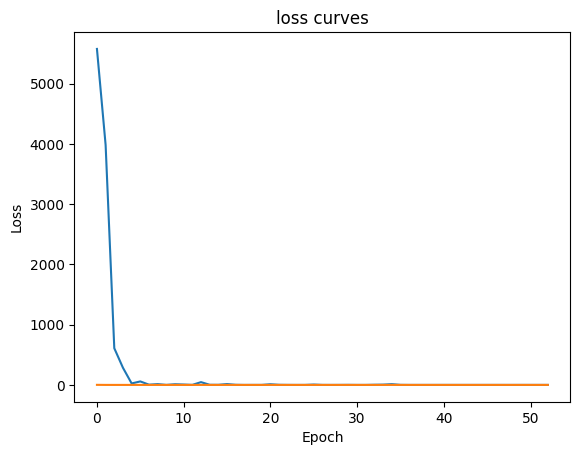

In [63]:
# loss curves
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss curves')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

1/1 [==============================] - 0s 61ms/step


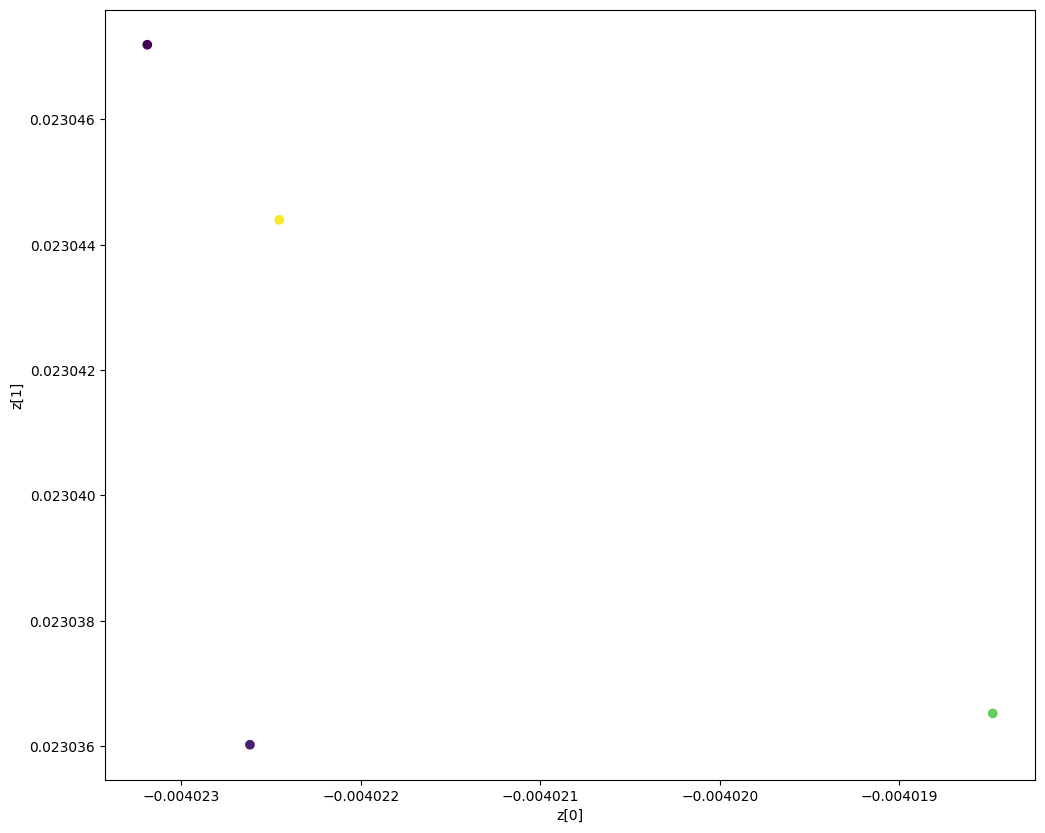

In [64]:
# 2D plot of the classes in latent space
z_m, _, _ = encoder.predict(X_test,batch_size=batch_size)
plt.figure(figsize=(12, 10))
plt.scatter(z_m[:, 0], z_m[:, 1], c=X_test[:,0,0,0])
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.show()

In [65]:
# predicting on validation data
pred=vae.predict(X_test)

1/1 [==============================] - 0s 140ms/step


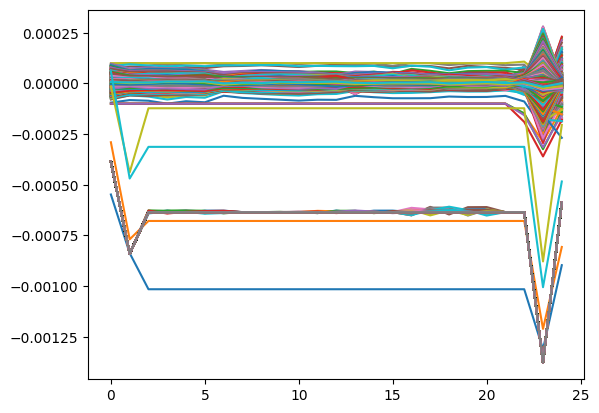

In [66]:
# observing generated signals
plt.plot(X_test[0,:,:,0])
plt.plot(pred[0,:,:,0])

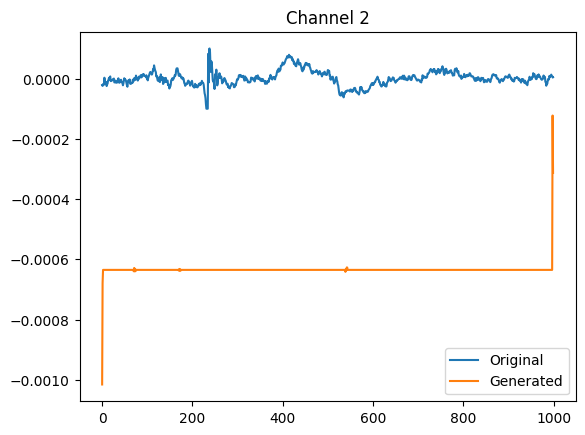

In [73]:
import matplotlib.pyplot as plt

channel = 2  # choose channel index

plt.figure()
plt.plot(X_test[0, channel, :, 0], label="Original")
plt.plot(pred[0, channel, :, 0], label="Generated")
plt.legend()
plt.title(f"Channel {channel}")
plt.show()


In [ ]:
x_hat = vae.predict(X_test)


-1000.0 419.43359375


NameError: name 'X_generated' is not defined